# Programming for Economists: Data Project

**Table of contents**<a id='toc0_'></a>    
- 1. [Aggregate inflation in Denmark](#toc1_)    
  - 1.1. [Data](#toc1_1_)    
  - 1.2. [Month-to-month inflation rate](#toc1_2_)    
  - 1.3. [12-month inflation rate](#toc1_3_)    
  - 1.4. [Instantaneous inflation](#toc1_4_)    
    - 1.4.1. [Weights](#toc1_4_1_)    
    - 1.4.2. [Results](#toc1_4_2_)    
  - 1.5. [Core inflation](#toc1_5_)    
- 2. [Disaggregated Inflation in Denmark](#toc2_)    
  - 2.1. [Data](#toc2_1_)    
  - 2.2. [Distribution over time](#toc2_2_)    
  - 2.3. [Price changes since 2020](#toc2_3_)    
    - 2.3.1. [Data](#toc2_3_1_)    
    - 2.3.2. [Histogram](#toc2_3_2_)    
    - 2.3.3. [Top and bottom](#toc2_3_3_)    
- 3. [International comparison](#toc3_)    
  - 3.1. [Denmark: CPI vs HICP](#toc3_1_)    
  - 3.2. [Cross-country](#toc3_2_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

from dstapi import DstApi
from fredapi import Fred

## 1. <a id='toc1_'></a>[Aggregate inflation in Denmark](#toc0_)

### 1.1. <a id='toc1_1_'></a>[Data](#toc0_)

In [2]:
PRIS113 = DstApi('PRIS113')

In [3]:
PRIS113.tablesummary(language='en')

Table PRIS113: Consumer price index by type and time
Last update: 2025-11-10T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,TYPE,1,INDEKS,Consumer price index,INDEKS,Consumer price index,False
1,Tid,550,1980M01,1980M01,2025M10,2025M10,True


In [4]:
# a. download data
params = PRIS113._define_base_params()
df_CPI = PRIS113.get_data(params)

# b. clean data
df_CPI = df_CPI.drop(columns=['TYPE'])
df_CPI['TID'] = pd.to_datetime(df_CPI['TID'],format='%YM%m')
df_CPI = df_CPI.rename(columns={'TID':'date','INDHOLD':'CPI'})
df_CPI = df_CPI.set_index('date').sort_index()

# c. index to 2020=100
df_CPI.CPI = df_CPI.CPI/df_CPI[df_CPI.index.year==2020].CPI.mean()*100
df_CPI.tail()

,CPI
date,
2025-06-01,116.693522
2025-07-01,118.433774
2025-08-01,117.660329
2025-09-01,117.563648
2025-10-01,118.047051


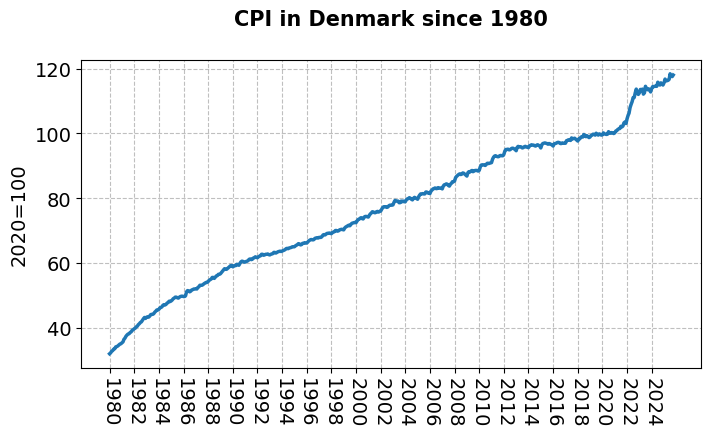

In [5]:
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,1,1)

ax.plot(df_CPI.index,df_CPI.CPI,lw=2.5)

ax.set_xticks(df_CPI.index[::24])
ax.set_xticklabels(df_CPI.index[::24].year,rotation=270);

ax.set_ylabel('2020=100')
ax.set_title('CPI in Denmark since 1980',
             pad=25.0,fontdict={'fontsize':15,'fontweight':'bold'});

### 1.2. <a id='toc1_2_'></a>[Month-to-month inflation rate](#toc0_)

In [6]:
df_CPI['inflation'] = df_CPI['CPI'].pct_change(periods=1,fill_method=None)*100

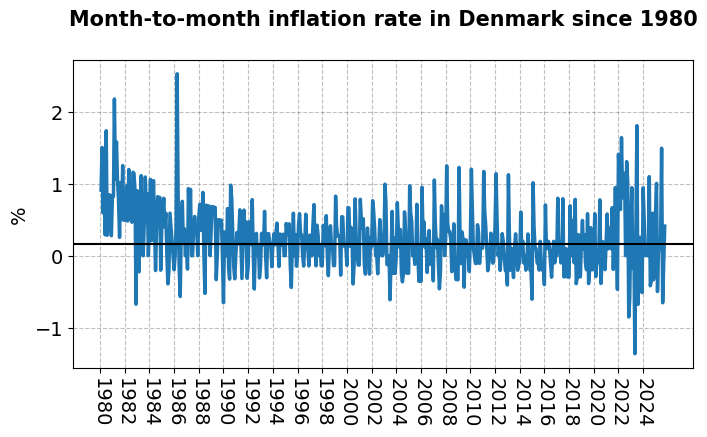

In [7]:
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,1,1)

ax.plot(df_CPI.index,df_CPI['inflation'],lw=2.5)

ax.axhline(((1+0.02)**(1/12)-1)*100,color='black')

ax.set_xticks(df_CPI.index[::24])
ax.set_xticklabels(df_CPI.index[::24].year,rotation=270);

ax.set_ylabel('%')
ax.set_title('Month-to-month inflation rate in Denmark since 1980',
             pad=25.0,fontdict={'fontsize':15,'fontweight':'bold'});

### 1.3. <a id='toc1_3_'></a>[12-month inflation rate](#toc0_)

In [8]:
df_CPI['inflation_12'] = df_CPI['CPI'].pct_change(periods=12)*100

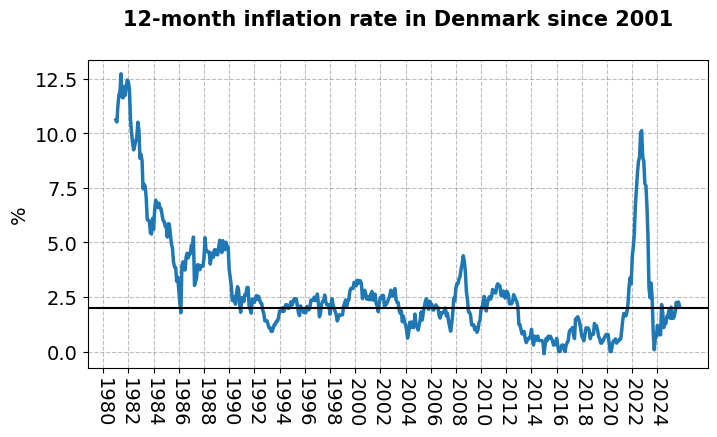

In [9]:
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,1,1)

ax.plot(df_CPI.index,df_CPI['inflation_12'],lw=2.5)

ax.axhline(2.0,color='black')

ax.set_xticks(df_CPI.index[::24])
ax.set_xticklabels(df_CPI.index[::24].year,rotation=270);

ax.set_ylabel('%')
ax.set_title('12-month inflation rate in Denmark since 2001',
             pad=25.0,fontdict={'fontsize':15,'fontweight':'bold'});

### 1.4. <a id='toc1_4_'></a>[Instantaneous inflation](#toc0_)

#### 1.4.1. <a id='toc1_4_1_'></a>[Weights](#toc0_)

In [10]:
a_vec = np.array([0.0,1.0,2.0,3.0])
Na = a_vec.size
weights = np.zeros((Na,12))
for i_a in range(Na):
    weights[i_a] = (12-np.flip(np.arange(12)))**a_vec[i_a]
    weights[i_a] = weights[i_a]/np.sum(weights[i_a])*12

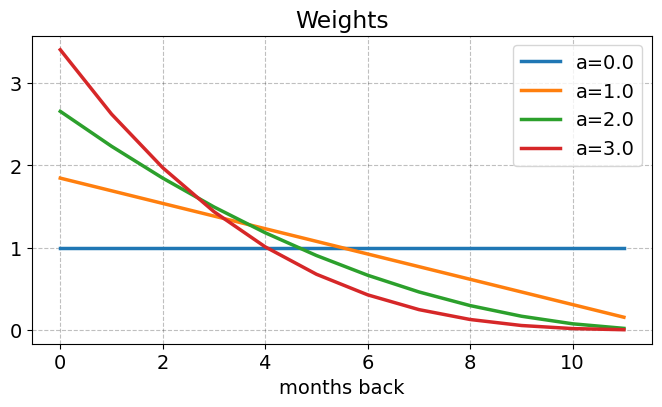

In [11]:
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,1,1)

for i_a in range(Na):
    ax.plot(np.flip(np.arange(12)),weights[i_a],label=f'a={a_vec[i_a]:.1f}',lw=2.5)

ax.legend()
ax.set_xlabel('months back')
ax.set_title('Weights');

#### 1.4.2. <a id='toc1_4_2_'></a>[Results](#toc0_)

In [12]:
for i_a in range(Na):
    df_CPI[f'inflation_{i_a}'] = df_CPI.inflation.rolling(12).apply(lambda x: (np.prod((1+x/100)**(weights[i_a]))-1)*100)

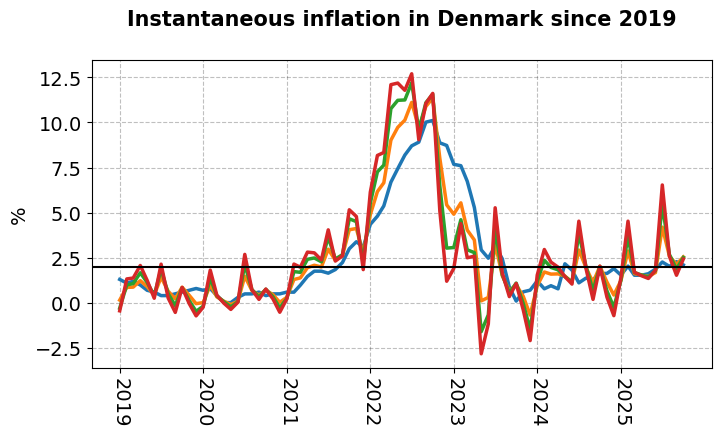

In [13]:
I = df_CPI.index >= pd.to_datetime(2019,format='%Y')

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,1,1)

for i_a in range(Na):
    ax.plot(df_CPI[I].index,df_CPI[I][f'inflation_{i_a}'],lw=2.5)

ax.axhline(2,color='black')

ax.set_xticks(df_CPI[I].index[::12])
ax.set_xticklabels(df_CPI[I].index[::12].year,rotation=270);

ax.set_ylabel('%')
ax.set_title('Instantaneous inflation in Denmark since 2019',
             pad=25.0,fontdict={'fontsize':15,'fontweight':'bold'});

### 1.5. <a id='toc1_5_'></a>[Core inflation](#toc0_)

In [14]:
PRIS111 = DstApi('PRIS111')

In [15]:
PRIS111.tablesummary(language='en')

Table PRIS111: Consumer price index by commodity group, unit and time
Last update: 2025-11-10T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,VAREGR,385,000000,"00 Consumer price index, total",151000,15.1 Overall Consumer Price Index excl. energy,False
1,ENHED,3,100,Index,300,Percentage change compared to same month the y...,False
2,Tid,298,2001M01,2001M01,2025M10,2025M10,True


In [16]:
PRIS111 = DstApi('PRIS111')
dict_VAREGR = {row['id']: row['text'] for i,row in PRIS111.variable_levels('VAREGR',language='en').iterrows()}
dict_ENHED = {row['id']: row['text'] for i,row in PRIS111.variable_levels('ENHED',language='en').iterrows()}

In [17]:
# a. download data
params = PRIS111._define_base_params(language='en')
VAREGR = {'code': 'VAREGR', 'values': ['000000', '141000','151000']}
ENHED = {'code': 'ENHED', 'values': ['100']}
TID = {'code': 'Tid', 'values': ['*']}
params['variables'] = [VAREGR, ENHED, TID]
df_CPI_core = PRIS111.get_data(params)

# b. clean data
df_CPI_core['VAREGR'] = df_CPI_core.VAREGR.replace(
    {dict_VAREGR['000000']: 'Total',
     dict_VAREGR['141000']: 'Core',
     dict_VAREGR['151000']: 'NonFood'
    })
df_CPI_core = df_CPI_core.rename(columns={'TID':'date','INDHOLD': 'value',})
df_CPI_core = df_CPI_core.drop(columns=['ENHED'])
df_CPI_core['date'] = pd.to_datetime(df_CPI_core['date'], format='%YM%m')
df_CPI_core['value'] = df_CPI_core.value.astype(float)

# c. pivot
df_CPI_core = df_CPI_core.pivot_table(index='date',columns='VAREGR',values='value').rename_axis(None,axis=1)

# d. inflation rates
df_CPI_core['inflation_12_total'] = df_CPI_core['Total'].pct_change(periods=12)*100
df_CPI_core['inflation_12_non_food'] = df_CPI_core['NonFood'].pct_change(periods=12)*100
df_CPI_core['inflation_12_core'] = df_CPI_core['Core'].pct_change(periods=12)*100
df_CPI_core.tail()

,Core,NonFood,Total,inflation_12_total,inflation_12_non_food,inflation_12_core
date,,,,,,
2025-06-01,119.4,120.2,120.7,1.856540,2.037351,1.877133
2025-07-01,121.1,121.9,122.5,2.253756,2.350966,2.194093
2025-08-01,120.4,121.2,121.7,2.011735,2.451395,2.293968
2025-09-01,120.3,121.1,121.6,2.270816,2.366864,2.209006
2025-10-01,120.6,121.4,122.1,2.090301,2.447257,2.290076


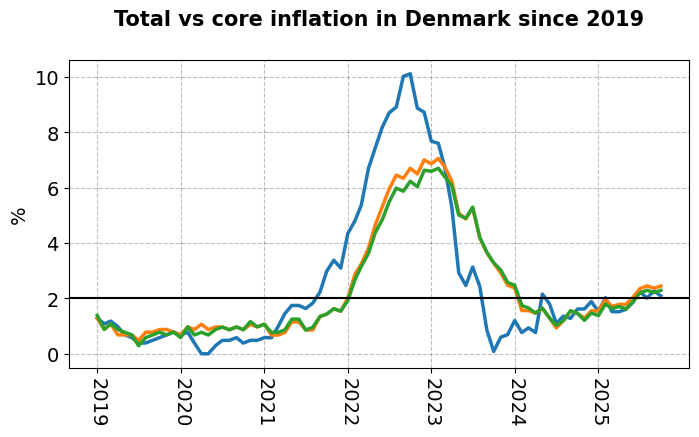

In [18]:
I = df_CPI_core.index >= pd.to_datetime(2019,format='%Y')

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,1,1)

ax.plot(df_CPI_core[I]['inflation_12_total'],lw=2.5,label='Total')
ax.plot(df_CPI_core[I]['inflation_12_non_food'],lw=2.5,label='Non-food')
ax.plot(df_CPI_core[I]['inflation_12_core'],lw=2.5,label='Core')

ax.axhline(2,color='black')

ax.set_xticks(df_CPI_core[I].index[::12])
ax.set_xticklabels(df_CPI_core[I].index[::12].year,rotation=270);

ax.set_ylabel('%')
ax.set_title('Total vs core inflation in Denmark since 2019',
             pad=25.0,fontdict={'fontsize':15,'fontweight':'bold'});

## 2. <a id='toc2_'></a>[Disaggregated Inflation in Denmark](#toc0_)

### 2.1. <a id='toc2_1_'></a>[Data](#toc0_)

List of categories:

In [19]:
levels = DstApi('PRIS111').variable_levels('VAREGR',language='en' )

def verify(id,text):
    cond_1 = not (id[-2] == '0' and id[-1] == '0')
    cond_2 = not ('/' in text.split(' ')[0] or '-' in text.split(' ')[0])
    return cond_1 and cond_2

VAREGR_text = [row['text'] for _,row in levels.iterrows() if verify(row['id'], row['text'])]
VAREGR = [row['id'] for _,row in levels.iterrows() if verify(row['id'], row['text'])]

print(f'{len(VAREGR)} categories found.')
print(VAREGR_text[30])

222 categories found.
01.1.6.1 Fresh or chilled fruit


Download data:

In [20]:
params = PRIS111._define_base_params(language='en')
VAREGR = {'code': 'VAREGR','values': VAREGR}
ENHED = {'code': 'ENHED','values': ['100']}
TID = {'code': 'Tid','values': ['*']}
params['variables'] = [VAREGR,ENHED,TID]
df_CPI_details = PRIS111.get_data(params)

Clean data:

In [21]:
df_CPI_details['TID'] = pd.to_datetime(df_CPI_details['TID'], format='%YM%m')
df_CPI_details = df_CPI_details.drop(columns='ENHED')
df_CPI_details = df_CPI_details.rename(columns={'TID':'date','VAREGR':'item','INDHOLD':'CPI'})
df_CPI_details.CPI = df_CPI_details.CPI.replace('..','nan')
df_CPI_details.CPI = df_CPI_details.CPI.astype(float)
df_CPI_details = df_CPI_details.sort_values(['item','date'])
df_CPI_details.tail()

,item,date,CPI
65430,12.7.0.3 Funeral services,2025-06-01,132.7
41017,12.7.0.3 Funeral services,2025-07-01,132.7
45468,12.7.0.3 Funeral services,2025-08-01,132.7
9576,12.7.0.3 Funeral services,2025-09-01,132.7
43055,12.7.0.3 Funeral services,2025-10-01,132.7


### 2.2. <a id='toc2_2_'></a>[Distribution over time](#toc0_)

In [22]:
df_CPI_details['inflation_12'] = df_CPI_details.groupby('item').CPI.transform(lambda x: x.pct_change(12, fill_method=None)*100)

In [23]:
df_CPI_details_agg = df_CPI_details.groupby('date').inflation_12.agg(
    p25 = lambda x: x.quantile(0.25),
    median = lambda x: x.quantile(0.5),
    p75 = lambda x: x.quantile(0.75),
    mean = 'mean'
    )
df_CPI_details_agg.tail()

,p25,median,p75,mean
date,,,,
2025-06-01,-1.555470,1.150442,3.624091,1.443190
2025-07-01,-0.098819,1.903974,4.087990,2.171646
2025-08-01,-0.492211,1.851852,3.865200,1.961282
2025-09-01,-1.154418,1.433121,4.061775,1.713398
2025-10-01,-0.385745,1.836158,4.677377,1.942890


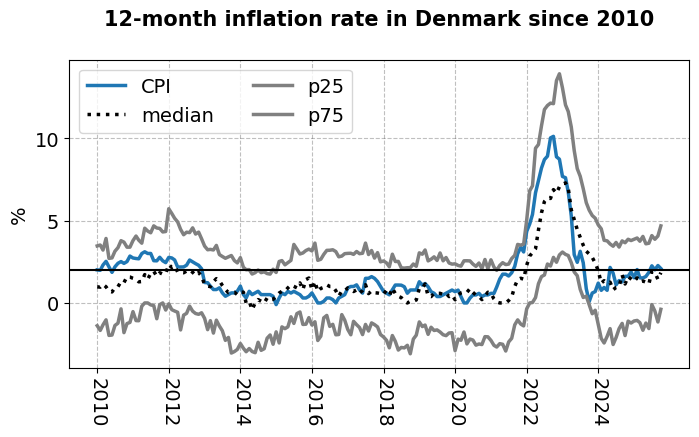

In [24]:
I = df_CPI.index >= pd.to_datetime(2010,format='%Y')
J = df_CPI_details_agg.index >= pd.to_datetime(2010,format='%Y')

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,1,1)

ax.plot(df_CPI[I].index,df_CPI[I]['inflation_12'],lw=2.5,label='CPI')
ax.plot(df_CPI_details_agg[J].index,df_CPI_details_agg[J]['median'],label='median',color='black',lw=2.5,ls=':')
for name in ['p25','p75']:
    ax.plot(df_CPI_details_agg[J].index,df_CPI_details_agg[J][name],label=name,color='grey',lw=2.5,ls='-')

ax.axhline(2.0,color='black')

ax.set_xticks(df_CPI[I].index[::24])
ax.set_xticklabels(df_CPI[I].index[::24].year,rotation=270);

ax.set_ylabel('%')
ax.legend(ncol=2)
ax.set_title('12-month inflation rate in Denmark since 2010',
             pad=25.0,fontdict={'fontsize': 15, 'fontweight': 'bold'});

### 2.3. <a id='toc2_3_'></a>[Price changes since 2020](#toc0_)

#### 2.3.1. <a id='toc2_3_1_'></a>[Data](#toc0_)

In [25]:
I = (df_CPI_details.date == '2020-08-01') | (df_CPI_details.date == '2025-08-01')
df_since_2020 = df_CPI_details[I].groupby('item').CPI.agg(['first','last'])
df_since_2020['change'] = (df_since_2020['last']/df_since_2020['first']-1)*100
df_since_2020 = df_since_2020.sort_values('change',ascending=False)
df_since_2020 = df_since_2020.dropna(subset=['change'])
df_since_2020.head().style.format('{:.1f}')


,first,last,change
item,,,
08.1.0.1 Letter handling services,211.7,382.3,80.6
01.2.1.1 Coffee,97.4,165.3,69.7
02.2.0.3 Other tobacco products,109.2,180.4,65.2
07.3.3.1 Domestic flights,72.5,118.0,62.8
01.1.5.1 Butter,123.5,194.0,57.1


#### 2.3.2. <a id='toc2_3_2_'></a>[Histogram](#toc0_)

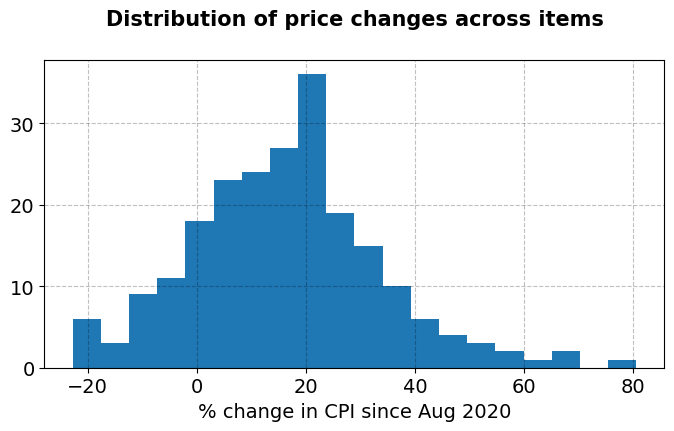

In [26]:
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,1,1)
ax.hist(df_since_2020.change.to_numpy(),bins=20)
ax.set_xlabel('% change in CPI since Aug 2020')
ax.set_title('Distribution of price changes across items',
                pad=25.0,fontdict={'fontsize': 15, 'fontweight': 'bold'});

#### 2.3.3. <a id='toc2_3_3_'></a>[Top and bottom](#toc0_)

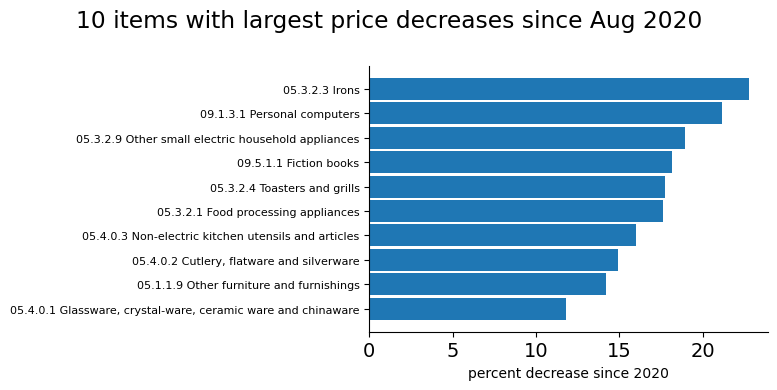

In [27]:
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,1,1)

ax.barh(df_since_2020[-10:].index, -df_since_2020[-10:].change.values,height=0.9)
ax.set_xlabel('percent decrease since 2020',fontsize=10)

ax.set_yticks(range(len(df_since_2020[-10:].index)))
ax.set_yticklabels(df_since_2020[-10:].index,fontsize=8)

ax.grid(False)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.suptitle('10 items with largest price decreases since Aug 2020')
fig.tight_layout()

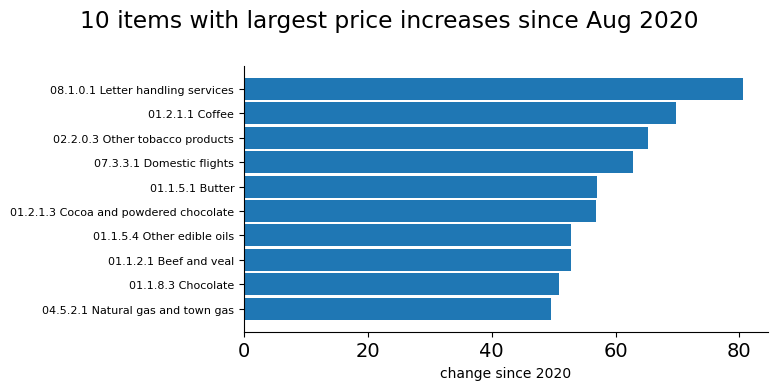

In [28]:
fig, ax = plt.subplots(figsize=(8,4))
ax.barh(np.flip(df_since_2020[:10].index), np.flip(df_since_2020[:10].change.values),height=0.9)
ax.set_xlabel('change since 2020',fontsize=10)

ax.set_yticks(range(len(df_since_2020[:10].index)))
ax.set_yticklabels(np.flip(df_since_2020[:10].index),fontsize=8)

ax.grid(False)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.suptitle('10 items with largest price increases since Aug 2020')
fig.tight_layout()

## 3. <a id='toc3_'></a>[International comparison](#toc0_)

In [29]:
with open('c:/Users/gmf123/Dropbox/fredapi.txt', 'r') as f: fred_api_key = f.read()
fred = Fred(api_key=fred_api_key)

### 3.1. <a id='toc3_1_'></a>[Denmark: CPI vs HICP](#toc0_)

In [30]:
df_CPI_HICP = df_CPI.loc[:,['CPI']]
df_CPI_HICP['HICP'] = fred.get_series('CP0000DKM086NEST').rename('HICP')
df_CPI_HICP['HICP'] = df_CPI_HICP.HICP/df_CPI_HICP[df_CPI_HICP.index.year==2020].HICP.mean()*100

In [31]:
df_CPI_HICP.tail()

,CPI,HICP
date,,
2025-06-01,116.693522,117.521264
2025-07-01,118.433774,119.465371
2025-08-01,117.660329,118.590522
2025-09-01,117.563648,118.396112
2025-10-01,118.047051,119.076549


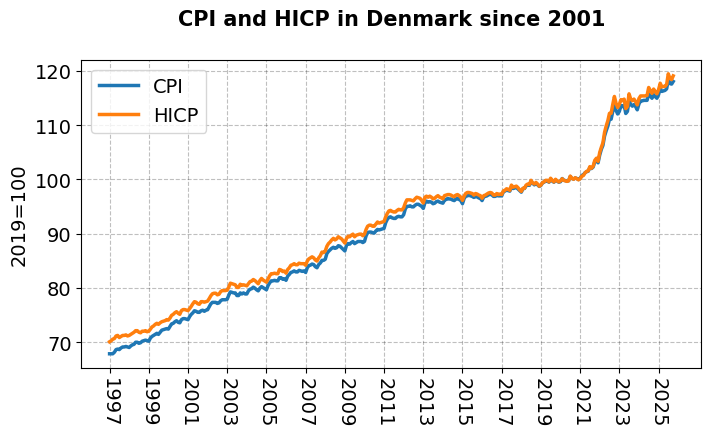

In [32]:
I = df_CPI_HICP.index >= pd.to_datetime(1997,format='%Y')

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,1,1)

ax.plot(df_CPI_HICP[I].index, df_CPI_HICP[I].CPI,lw=2.5,label='CPI')
ax.plot(df_CPI_HICP[I].index, df_CPI_HICP[I].HICP,lw=2.5,label='HICP')

ax.set_xticks(df_CPI_HICP[I].index[::24])
ax.set_xticklabels(df_CPI_HICP[I].index[::24].year,rotation=270);

ax.legend()
ax.set_ylabel('2019=100')
ax.set_title('CPI and HICP in Denmark since 2001',
             pad=25.0,fontdict={'fontsize':15,'fontweight':'bold'});

### 3.2. <a id='toc3_2_'></a>[Cross-country](#toc0_)

In [33]:
countries = {
    'Denmark': 'Denmark',
    'Austria': 'Austria',
    'EuroArea': 'Euro Area',
    'UnitedStates': 'United States',
}

series = {
    'CP0000DKM086NEST': 'Denmark',
    'CP0000ATM086NEST': 'Austria',
    'CP0000EZ19M086NEST': 'EuroArea',
    'CP0000USM086NEST': 'UnitedStates',    
}

Check data:

In [34]:
data = {}
for k,v in series.items():
    label = fred.search(k)[['title']].values[0][0]
    print(f'{v}: {label}')

Denmark: Harmonized Index of Consumer Prices: All-Items HICP for Denmark
Austria: Harmonized Index of Consumer Prices: All-Items HICP for Austria
EuroArea: Harmonized Index of Consumer Prices: All-Items HICP for Euro Area (19 Countries)
UnitedStates: Harmonized Index of Consumer Prices: All-Items HICP for United States


Download data:

In [35]:
data = {}
for code,name in series.items():
    data[name] = fred.get_series(code)
df_int = pd.DataFrame(data)

In [36]:
df_int = df_int/df_int[df_int.index.year==2020].mean()*100
df_int.tail()

,Denmark,Austria,EuroArea,UnitedStates
2025-06-01,117.521264,127.935957,122.820181,NaN
2025-07-01,119.465371,128.037369,122.820181,NaN
2025-08-01,118.590522,128.443017,123.010541,NaN
2025-09-01,118.396112,128.489114,123.124757,NaN
2025-10-01,119.076549,129.134463,123.381743,NaN


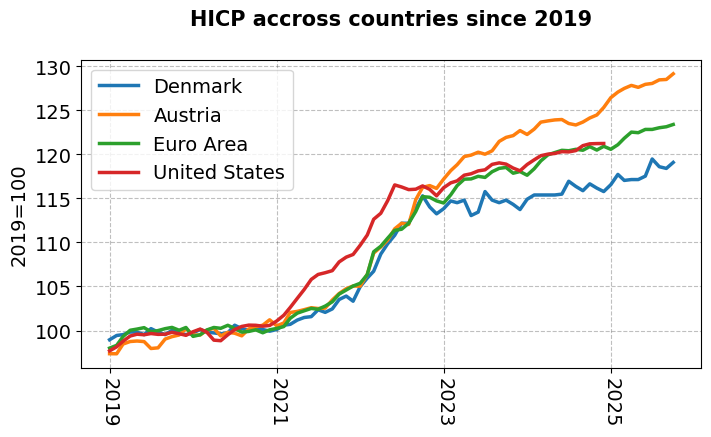

In [37]:
I = df_int.index >= pd.to_datetime(2019,format='%Y')

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,1,1)

for code, name in countries.items():
    ax.plot(df_int[I].index, df_int[I][code], lw=2.5,label=name)

ax.set_xticks(df_int[I].index[::24])
ax.set_xticklabels(df_int[I].index[::24].year,rotation=270);

ax.legend()
ax.set_ylabel('2019=100')
ax.set_title('HICP accross countries since 2019',
             pad=25.0,fontdict={'fontsize': 15, 'fontweight': 'bold'});

In [38]:
df_int_pct_change = df_int.pct_change(periods=12,fill_method=None)*100

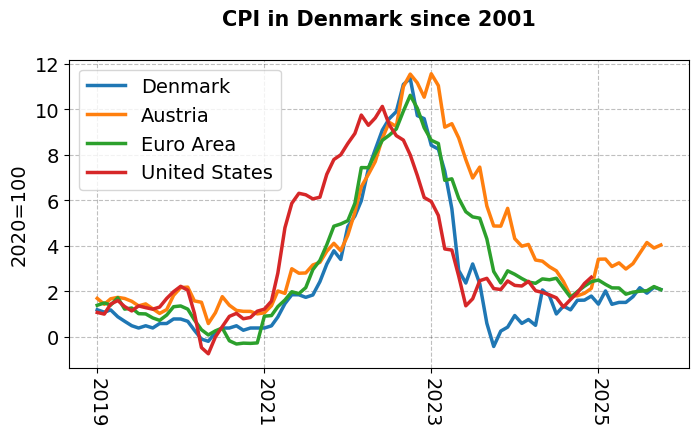

In [39]:
I = df_int_pct_change.index >= pd.to_datetime(2019,format='%Y')

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,1,1)

for code, name in countries.items():
    ax.plot(df_int_pct_change[I].index, df_int_pct_change[I][code], lw=2.5,label=name)

ax.set_xticks(df_int_pct_change[I].index[::24])
ax.set_xticklabels(df_int_pct_change[I].index[::24].year,rotation=270);

ax.legend()
ax.set_ylabel('2020=100')
ax.set_title('CPI in Denmark since 2001',
             pad=25.0,fontdict={'fontsize': 15, 'fontweight': 'bold'});

In [40]:
I = df_int_pct_change.index >= pd.to_datetime(2019,format='%Y')
df_int_pct_change[I].groupby(df_int_pct_change[I].index.year).agg(['min','mean','max']).round(1)

Denmark            Austria            EuroArea            UnitedStates  \
         min mean   max     min mean   max      min mean   max          min   
2019     0.4  0.7   1.2     1.0  1.5   1.8      0.7  1.2   1.7          1.0   
2020    -0.2  0.3   0.8     0.6  1.4   2.2     -0.3  0.3   1.4         -0.7   
2021     0.4  1.9   3.8     1.1  2.8   4.1      0.9  2.6   5.0          1.2   
2022     4.9  8.5  11.4     4.5  8.6  11.6      5.1  8.4  10.6          6.1   
2023    -0.4  3.4   8.4     4.9  7.8  11.6      2.4  5.5   8.6          1.4   
2024     0.5  1.3   2.1     1.8  2.9   4.3      1.7  2.4   2.8          1.3   
2025     1.4  1.8   2.2     3.0  3.5   4.1      1.9  2.1   2.5          NaN   

                 
     mean   max  
2019  1.4   2.0  
2020  0.8   2.2  
2021  5.3   8.0  
2022  8.7  10.1  
2023  3.0   6.0  
2024  2.0   2.6  
2025  NaN   NaN